In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import scipy.sparse as sp
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading

In [23]:
# Load datasets
books = pd.read_csv('Books.csv')
books_cat = pd.read_csv('Books_categories.csv', encoding='latin-1')

## 2. Data Cleaning

In [24]:
# Drop missing values and duplicates
books_cat = books_cat.dropna(subset=['text_clean', 'keyword_category'])
books_cat = books_cat.drop_duplicates(subset=['Title'])
books_cat = books_cat.reset_index(drop=True)

print(f"Dataset shape after cleaning: {books_cat.shape}")
print(f"\nGenre distribution:\n{books_cat['keyword_category'].value_counts().head(10)}")

Dataset shape after cleaning: (1985, 7)

Genre distribution:
keyword_category
other         539
fiction       401
history       287
military      243
travel        206
romantic      135
medical        52
business       42
scientific     35
psychology     33
Name: count, dtype: int64


## 3. Text Feature Engineering — TF-IDF

TF-IDF matrix shape: (1985, 5000)


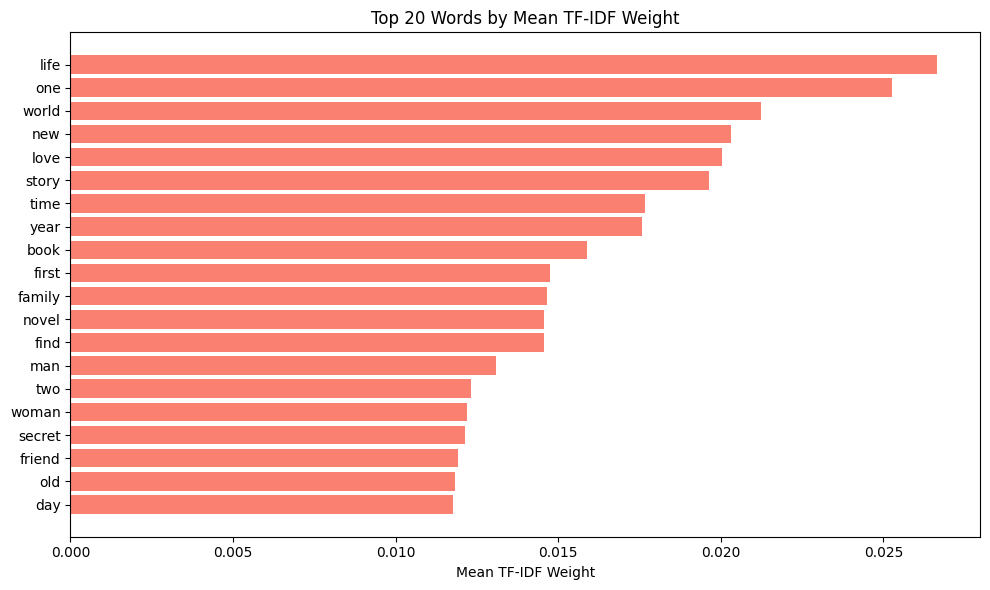

In [25]:
# TF-IDF vectorization on cleaned book descriptions
tfidf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(books_cat['text_clean'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

# Top 20 words by mean TF-IDF weight
tfidf_mean = tfidf_matrix.mean(axis=0).A1
feature_names_tfidf = tfidf.get_feature_names_out()
top20_tfidf_idx = tfidf_mean.argsort()[-20:][::-1]
top20_tfidf_words = [feature_names_tfidf[i] for i in top20_tfidf_idx]
top20_tfidf_scores = tfidf_mean[top20_tfidf_idx]

plt.figure(figsize=(10, 6))
plt.barh(top20_tfidf_words[::-1], top20_tfidf_scores[::-1], color='salmon')
plt.xlabel('Mean TF-IDF Weight')
plt.title('Top 20 Words by Mean TF-IDF Weight')
plt.tight_layout()
plt.savefig('tfidf_top20.png', dpi=150)
plt.show()

## 4. Clustering — K-Means

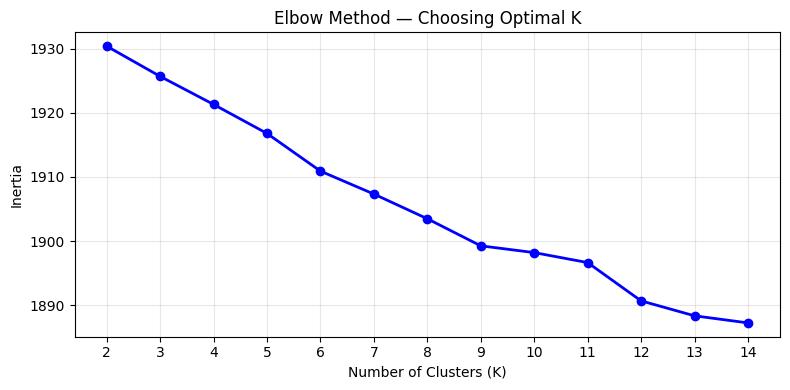

In [26]:
# Elbow method to determine optimal K
inertia = []
K_range = range(2, 15)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Choosing Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150)
plt.show()

### 4.1 Choosing Optimal K (Elbow Method)

In [27]:
# Train K-Means with K=6 (selected based on elbow plot)
K = 6
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
books_cat['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f"Books per cluster:\n{books_cat['cluster'].value_counts().sort_index()}")

Books per cluster:
cluster
0     94
1    210
2    408
3    493
4    752
5     28
Name: count, dtype: int64


### 4.2 K-Means Results

In [28]:
# Top keywords per cluster
feature_names = tfidf.get_feature_names_out()
cluster_centers = kmeans.cluster_centers_

for i in range(K):
    top_indices = cluster_centers[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"Cluster {i}: {', '.join(top_words)}")

Cluster 0: vampire, harry, sookie, zoey, anita, night, dresden, wizard, undead, harry dresden
Cluster 1: new, new york, york, time, york time, life, bestselling, time bestselling, one, city
Cluster 2: book, story, tale, classic, reader, adventure, first, world, one, edition
Cluster 3: life, family, story, love, novel, year, one, woman, two, young
Cluster 4: one, life, world, know, year, find, never, love, even, secret
Cluster 5: stephanie, de, plum, la, stephanie plum, bounty hunter, bounty, ranger, morelli, hunter


In [29]:
# Export outputs for teammates
books_cat.to_csv('books_with_clusters.csv', index=False)
sp.save_npz('tfidf_matrix.npz', tfidf_matrix)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

## 5. Clustering Evaluation — Silhouette Score

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_books_by_description(input_text, top_n=5):
    """
    Given a text description, find the most similar books
    using cosine similarity on TF-IDF vectors.
    """
    input_vector = tfidf.transform([input_text])
    sim_scores = cosine_similarity(input_vector, tfidf_matrix).flatten()
    top_indices = sim_scores.argsort()[-top_n:][::-1]

    results = books_cat.iloc[top_indices][['Title', 'keyword_category', 'cluster']].copy()
    results['similarity_score'] = sim_scores[top_indices].round(4)
    return results.reset_index(drop=True)

# Test
input_text = "A young wizard discovers his powers and enters a magical school."
recommend_books_by_description(input_text, top_n=5)

,Title,keyword_category,cluster,similarity_score
0,"Sourcery (Discworld, #5; Rincewind #3)",other,4,0.1986
1,"Equal Rites (Discworld, #3; Witches #1)",other,4,0.1568
2,The Tales of Beedle the Bard,military,2,0.1560
3,The Name of the Wind (The Kingkiller Chronicle...,fiction,2,0.1511
4,"Proven Guilty (The Dresden Files, #8)",military,0,0.1324


## 6. Content-Based Recommendation via Cosine Similarity

In [31]:
from sklearn.metrics import silhouette_score
score = silhouette_score(tfidf_matrix, books_cat['cluster'], sample_size=500)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.0036


## 7. Bag-of-Words (BoW) Feature Representation

BoW matrix shape: (1985, 5000)


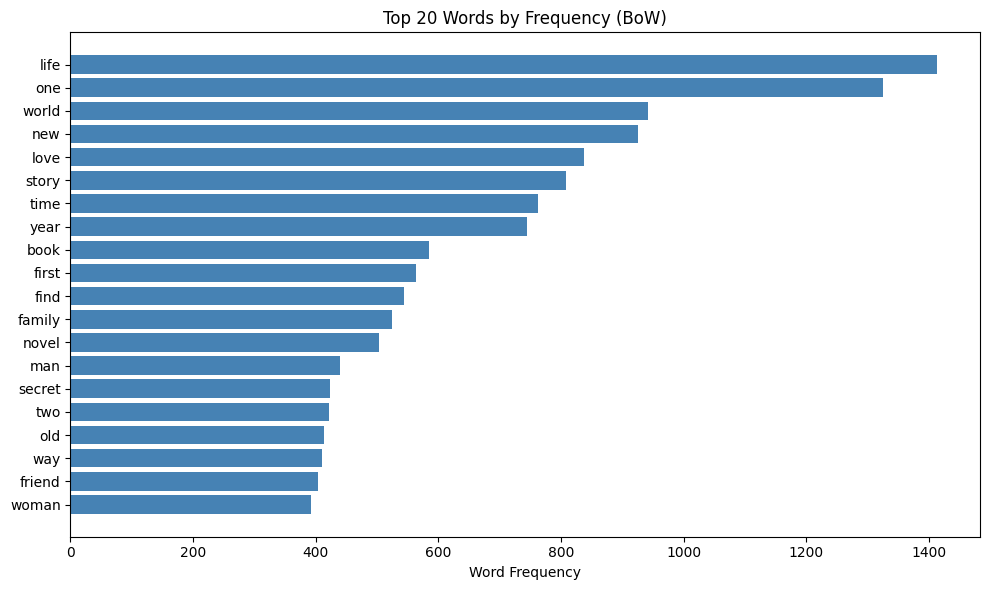

In [32]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import numpy as np

# BoW vectorization
bow = CountVectorizer(max_features=5000, min_df=2, max_df=0.95)
bow_matrix = bow.fit_transform(books_cat['text_clean'])
print(f"BoW matrix shape: {bow_matrix.shape}")

# Top 20 words by frequency
word_freq = np.asarray(bow_matrix.sum(axis=0)).flatten()
feature_names = bow.get_feature_names_out()
top20_idx = word_freq.argsort()[-20:][::-1]
top20_words = [feature_names[i] for i in top20_idx]
top20_freq = word_freq[top20_idx]

plt.figure(figsize=(10, 6))
plt.barh(top20_words[::-1], top20_freq[::-1], color='steelblue')
plt.xlabel('Word Frequency')
plt.title('Top 20 Words by Frequency (BoW)')
plt.tight_layout()
plt.savefig('bow_frequency.png', dpi=150)
plt.show()

## 8. Cluster Visualization (PCA)

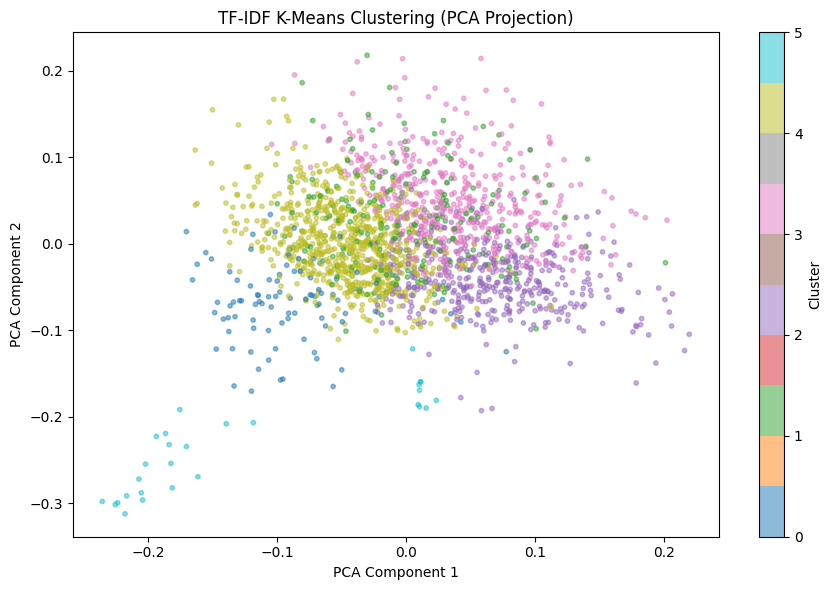

In [33]:
from sklearn.decomposition import PCA

# Reduce TF-IDF to 2D using PCA
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    reduced[:, 0], reduced[:, 1],
    c=books_cat['cluster'],
    cmap='tab10',
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label='Cluster')
plt.title('TF-IDF K-Means Clustering (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=150)
plt.show()

## 9. Genre Distribution

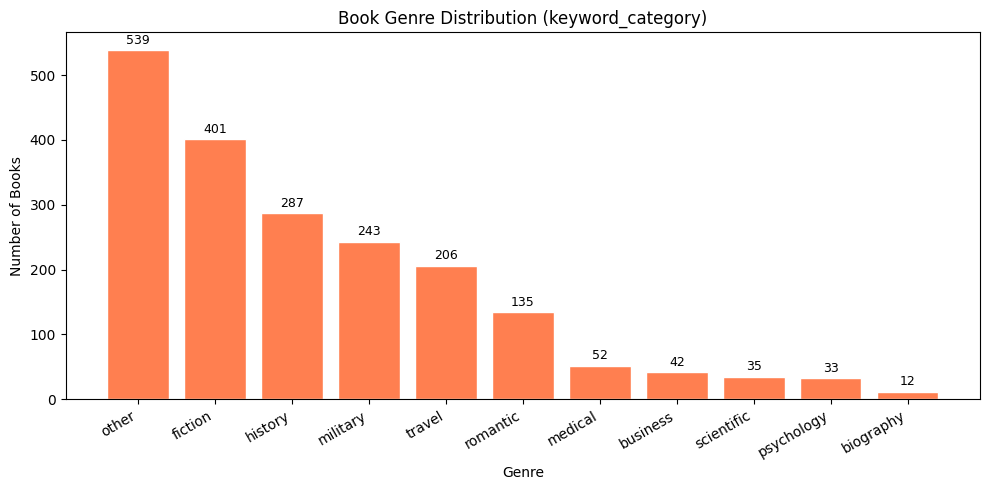

In [34]:
genre_counts = books_cat['keyword_category'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(genre_counts.index, genre_counts.values, color='coral', edgecolor='white')
plt.title('Book Genre Distribution (keyword_category)')
plt.xlabel('Genre')
plt.ylabel('Number of Books')
plt.xticks(rotation=30, ha='right')

for bar, count in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

## 10. Kappa Score

In [35]:
from sklearn.metrics import cohen_kappa_score

# Encode keyword_category as numbers for kappa calculation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels = le.fit_transform(books_cat['keyword_category'])
predicted_clusters = books_cat['cluster']

kappa = cohen_kappa_score(true_labels, predicted_clusters)
print(f"Cohen's Kappa Score: {kappa:.4f}")
print(f"Silhouette Score: {score:.4f}")

Cohen's Kappa Score: 0.0317
Silhouette Score: 0.0036


## 11. LDA Feature Representation

LDA matrix shape: (1985, 10)


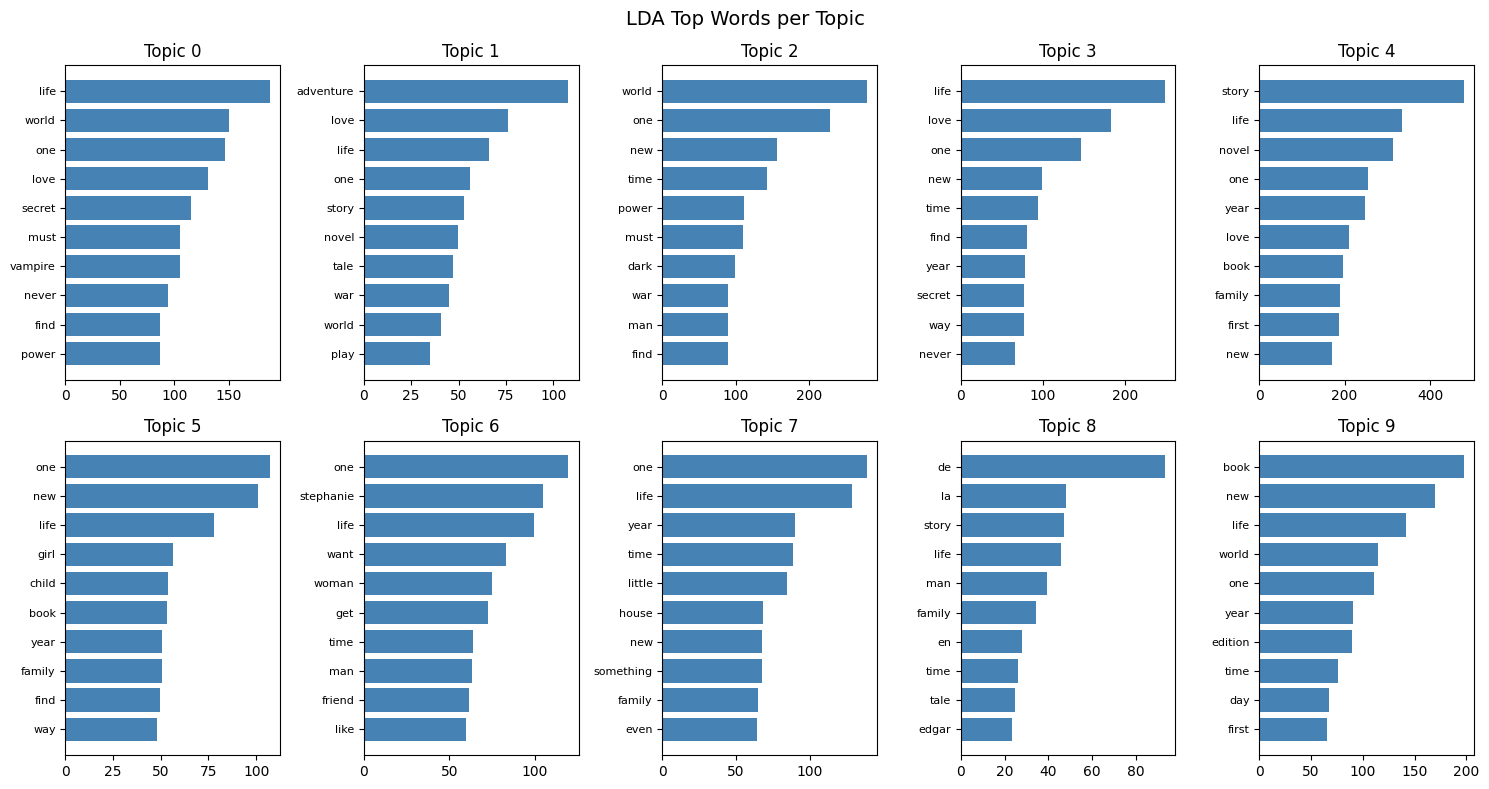

In [36]:
# LDA features
from sklearn.decomposition import LatentDirichletAllocation

lda_model = LatentDirichletAllocation(
    n_components=10, random_state=42, learning_method='batch'
)
lda_matrix = lda_model.fit_transform(bow_matrix)
print(f"LDA matrix shape: {lda_matrix.shape}")

# Top words per LDA topic
feature_names_bow = bow.get_feature_names_out()
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    top_idx = lda_model.components_[i].argsort()[-10:][::-1]
    top_words = [feature_names_bow[j] for j in top_idx]
    top_scores = lda_model.components_[i][top_idx]
    ax.barh(top_words[::-1], top_scores[::-1], color='steelblue')
    ax.set_title(f'Topic {i}')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('LDA Top Words per Topic', fontsize=14)
plt.tight_layout()
plt.savefig('lda_topics.png', dpi=150)
plt.show()

## 12. Word2Vec Feature Representation

Word2Vec matrix shape: (1985, 100)


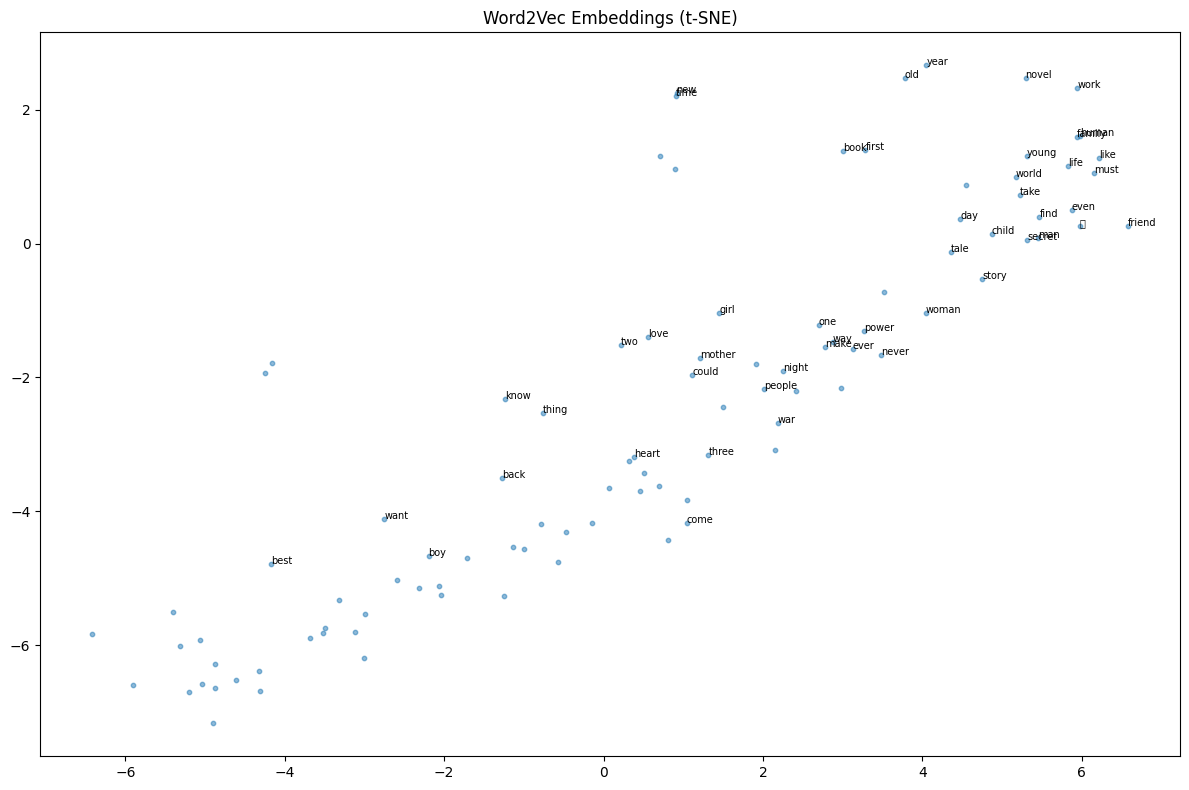

In [38]:
# Word2Vec features
from gensim.models import Word2Vec
import numpy as np

tokens = [text.split() for text in books_cat['text_clean']]
w2v_model = Word2Vec(sentences=tokens, vector_size=100, window=5, min_count=2, workers=4, seed=42)

def document_vector(tokens, model, dim):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

w2v_matrix = np.array([document_vector(t, w2v_model, 100) for t in tokens])
print(f"Word2Vec matrix shape: {w2v_matrix.shape}")

from sklearn.manifold import TSNE

# Get all word vectors
words = list(w2v_model.wv.index_to_key[:100])
vectors = np.array([w2v_model.wv[word] for word in words])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_w2v = tsne.fit_transform(vectors)

plt.figure(figsize=(12, 8))
plt.scatter(reduced_w2v[:, 0], reduced_w2v[:, 1], alpha=0.5, s=10)
for i, word in enumerate(words[:50]):
    plt.annotate(word, (reduced_w2v[i, 0], reduced_w2v[i, 1]), fontsize=7)
plt.title('Word2Vec Embeddings (t-SNE)')
plt.tight_layout()
plt.savefig('word2vec_tsne.png', dpi=150)
plt.show()

## 13. GMM Clustering

GMM cluster distribution:
cluster_gmm
0    345
1    160
2    388
3    171
4    608
5    313
Name: count, dtype: int64


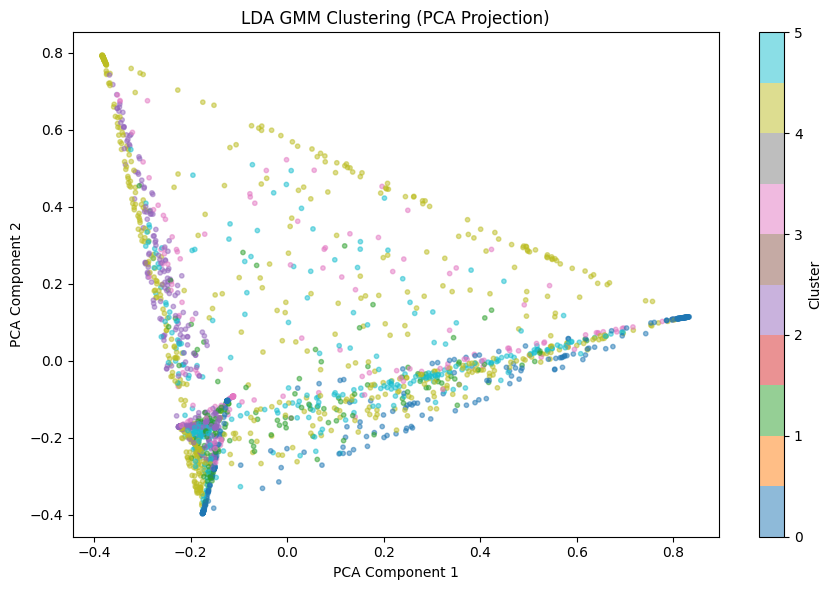

In [ ]:
# GMM clustering
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=6, random_state=42)
books_cat['cluster_gmm'] = gmm.fit_predict(lda_matrix)
print(f"GMM cluster distribution:\n{books_cat['cluster_gmm'].value_counts().sort_index()}")

pca_gmm = PCA(n_components=2, random_state=42)
reduced_lda = pca_gmm.fit_transform(lda_matrix)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    reduced_lda[:, 0], reduced_lda[:, 1],
    c=books_cat['cluster_gmm'],
    cmap='tab10', alpha=0.5, s=10
)
plt.colorbar(scatter, label='Cluster')
plt.title('LDA GMM Clustering (PCA Projection)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('gmm_pca.png', dpi=150)
plt.show()

## 14. Clustering Evaluation Comparison

                 Silhouette   Kappa
TF-IDF KMeans        0.0046  0.0317
BoW KMeans           0.0862  0.0005
LDA KMeans           0.3046  0.0120
LDA GMM             -0.0054 -0.0224
Word2Vec KMeans      0.4402 -0.0079


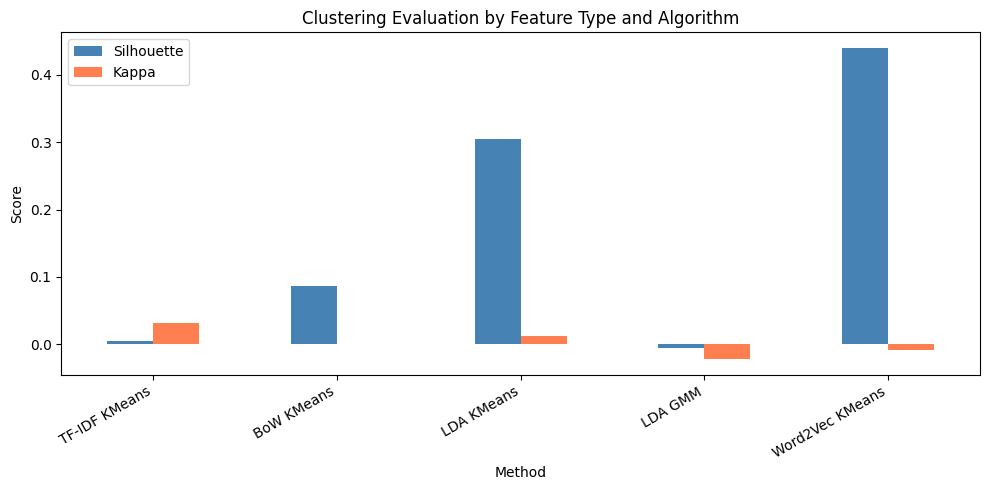

In [ ]:
# Clustering evaluation comparison table
from sklearn.metrics import silhouette_score, cohen_kappa_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
true_labels = le.fit_transform(books_cat['keyword_category'])

results = {}

# TF-IDF + KMeans
results['TF-IDF KMeans'] = {
    'Silhouette': silhouette_score(tfidf_matrix, books_cat['cluster'], sample_size=500),
    'Kappa': cohen_kappa_score(true_labels, books_cat['cluster'])
}

# BoW + KMeans
from sklearn.cluster import KMeans
km_bow = KMeans(n_clusters=6, random_state=42, n_init=10)
bow_clusters = km_bow.fit_predict(bow_matrix)
results['BoW KMeans'] = {
    'Silhouette': silhouette_score(bow_matrix, bow_clusters, sample_size=500),
    'Kappa': cohen_kappa_score(true_labels, bow_clusters)
}

# LDA + KMeans
km_lda = KMeans(n_clusters=6, random_state=42, n_init=10)
lda_clusters = km_lda.fit_predict(lda_matrix)
results['LDA KMeans'] = {
    'Silhouette': silhouette_score(lda_matrix, lda_clusters, sample_size=500),
    'Kappa': cohen_kappa_score(true_labels, lda_clusters)
}

# LDA + GMM
results['LDA GMM'] = {
    'Silhouette': silhouette_score(lda_matrix, books_cat['cluster_gmm'], sample_size=500),
    'Kappa': cohen_kappa_score(true_labels, books_cat['cluster_gmm'])
}

# Word2Vec + KMeans
km_w2v = KMeans(n_clusters=6, random_state=42, n_init=10)
w2v_clusters = km_w2v.fit_predict(w2v_matrix)
results['Word2Vec KMeans'] = {
    'Silhouette': silhouette_score(w2v_matrix, w2v_clusters, sample_size=500),
    'Kappa': cohen_kappa_score(true_labels, w2v_clusters)
}

import pandas as pd
results_df = pd.DataFrame(results).T.round(4)
print(results_df)

results_df[['Silhouette', 'Kappa']].plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'])
plt.title('Clustering Evaluation by Feature Type and Algorithm')
plt.xlabel('Method')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150)
plt.show()